## **Teste do Modelo**

Nesta etapa, o modelo YOLO treinado é aplicado em novas imagens para verificar visualmente a detecção de helipontos

In [10]:
import matplotlib.pyplot as plt
from ultralytics import YOLO
from glob import glob

# Carrega o modelo UMA vez só
model = YOLO('AI Training/runs/detect/runs/exp1-2/weights/best.pt')

# Lista as imagens de teste
path_images = glob('New Images/*.jpg')

for path_image in path_images:
    # Faz a predição
    results = model.predict(
        source=path_image,
        save=True,   # salva no runs/detect/predict...
        conf=0.25
    )

    # Cria figura com 2 subplots
    fig, (left, right) = plt.subplots(1, 2, figsize=(12, 6))

    # Imagem original
    left.imshow(plt.imread(path_image))
    left.axis('off')
    left.set_title("Imagem Original")

    # Imagem com detecção (results[0].plot() retorna array BGR)
    annotated = results[0].plot()
    right.imshow(annotated[:, :, ::-1])  # BGR -> RGB
    right.axis('off')
    right.set_title("Detecção de Heliponto")

    plt.tight_layout()
    plt.show()

# **Análise do Modelo**

In [11]:
import seaborn as sns
import pandas as pd

results_df = pd.read_csv('AI Training/runs/detect/runs/exp1-2/results.csv')
results_df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,6.39574,1.33875,3.44081,1.55389,0.00333,1.00000,0.78755,0.35795,1.19157,3.84870,1.39824,0.000220,0.000220,0.000220
1,2,10.26110,1.26203,2.87580,1.41426,0.00333,1.00000,0.53566,0.21643,1.25508,4.43820,1.62955,0.000452,0.000452,0.000452
2,3,14.44790,1.21268,2.49484,1.36679,0.00333,1.00000,0.38349,0.11105,1.20832,4.20107,1.62336,0.000677,0.000677,0.000677
3,4,17.85260,1.29544,2.51040,1.44549,0.46138,0.50000,0.45409,0.15175,1.95158,4.22150,2.52903,0.000893,0.000893,0.000893
4,5,21.17220,1.24292,2.37024,1.35180,0.60966,0.41176,0.53603,0.19813,2.11168,3.72196,2.29056,0.001102,0.001102,0.001102
5,6,25.53310,1.13395,2.12609,1.28154,0.45876,0.50000,0.50847,0.17107,1.58378,3.69532,1.99045,0.001303,0.001303,0.001303
6,7,28.82460,1.16481,2.02161,1.36591,0.59728,0.55882,0.55692,0.17752,2.05979,3.36952,2.67046,0.001496,0.001496,0.001496
7,8,32.09310,1.26049,2.05527,1.45221,0.64503,0.58792,0.62954,0.27102,2.14000,3.60696,3.07444,0.001681,0.001681,0.001681
8,9,35.68850,1.25084,2.94947,1.38563,0.71737,0.79412,0.76780,0.46062,2.02934,3.33537,2.00283,0.001736,0.001736,0.001736
9,10,39.77500,1.37080,2.32565,1.49888,0.54018,0.50000,0.58446,0.31093,1.68304,6.84381,2.08487,0.001703,0.001703,0.001703


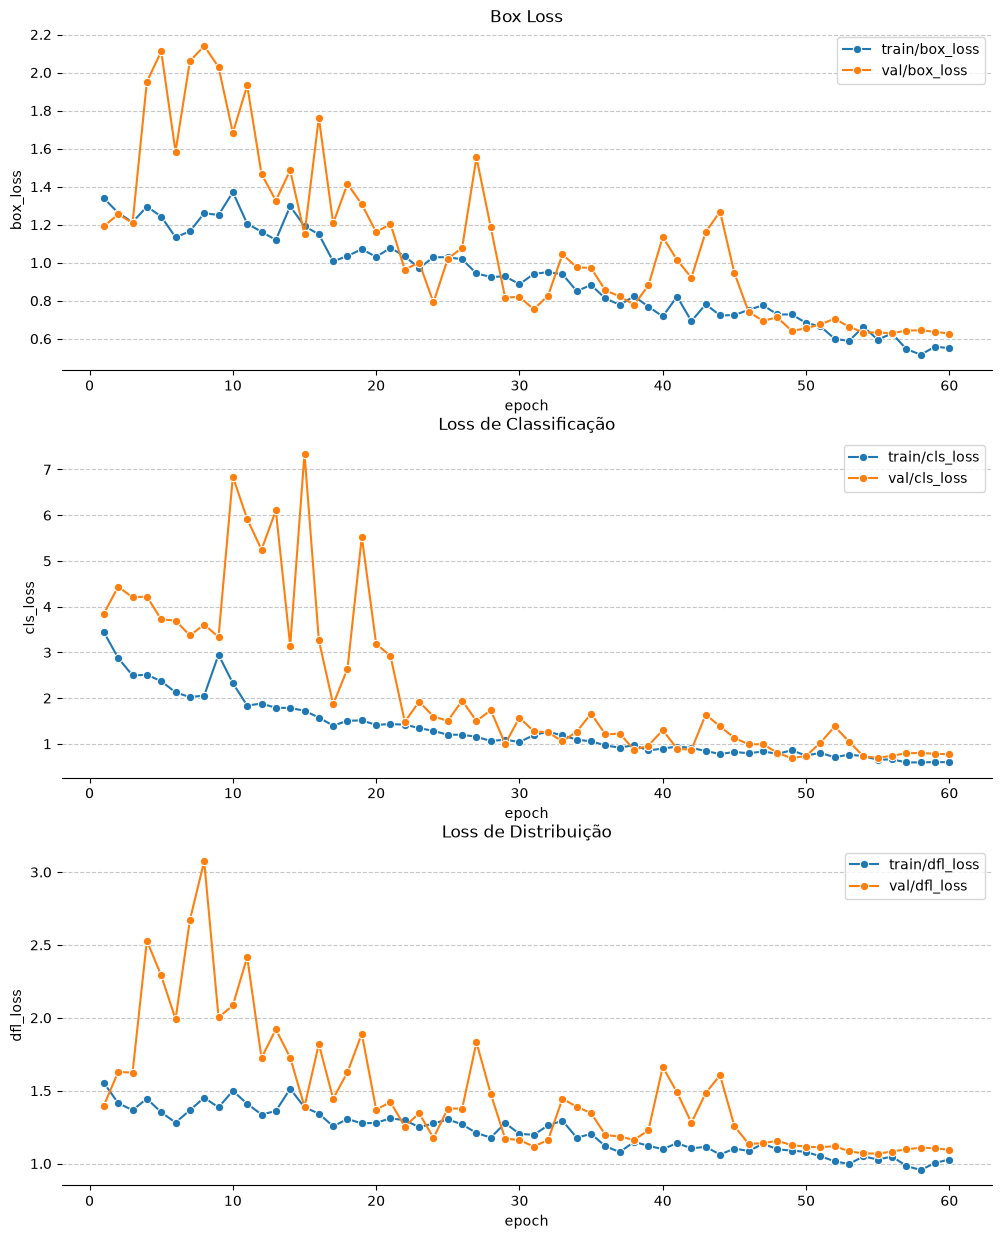

In [12]:
fig, (up, middle, down) = plt.subplots(3, 1, figsize=(12, 15))

sns.lineplot(data=results_df, x='epoch', y='train/box_loss', marker='o', linestyle='-', label='train/box_loss', ax=up)
sns.lineplot(data=results_df, x='epoch', y='val/box_loss', marker='o', linestyle='-', label='val/box_loss', ax=up)
up.set_title("Box Loss")
up.set_ylabel("box_loss")
up.spines['top'].set_visible(False)
up.spines['right'].set_visible(False)
up.spines['left'].set_visible(False)
up.grid(axis='y', linestyle='--', alpha=0.7)


sns.lineplot(data=results_df, x='epoch', y='train/cls_loss', marker='o', linestyle='-', label='train/cls_loss', ax=middle)
sns.lineplot(data=results_df, x='epoch', y='val/cls_loss', marker='o', linestyle='-', label='val/cls_loss', ax=middle)
middle.set_title("Loss de Classificação")
middle.set_ylabel("cls_loss")
middle.spines['top'].set_visible(False)
middle.spines['right'].set_visible(False)
middle.spines['left'].set_visible(False)
middle.grid(axis='y', linestyle='--', alpha=0.7)


sns.lineplot(data=results_df, x='epoch', y='train/dfl_loss', marker='o', linestyle='-', label='train/dfl_loss', ax=down)
sns.lineplot(data=results_df, x='epoch', y='val/dfl_loss', marker='o', linestyle='-', label='val/dfl_loss', ax=down)
down.set_title("Loss de Distribuição")
down.set_ylabel("dfl_loss")
down.spines['top'].set_visible(False)
down.spines['right'].set_visible(False)
down.spines['left'].set_visible(False)
down.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

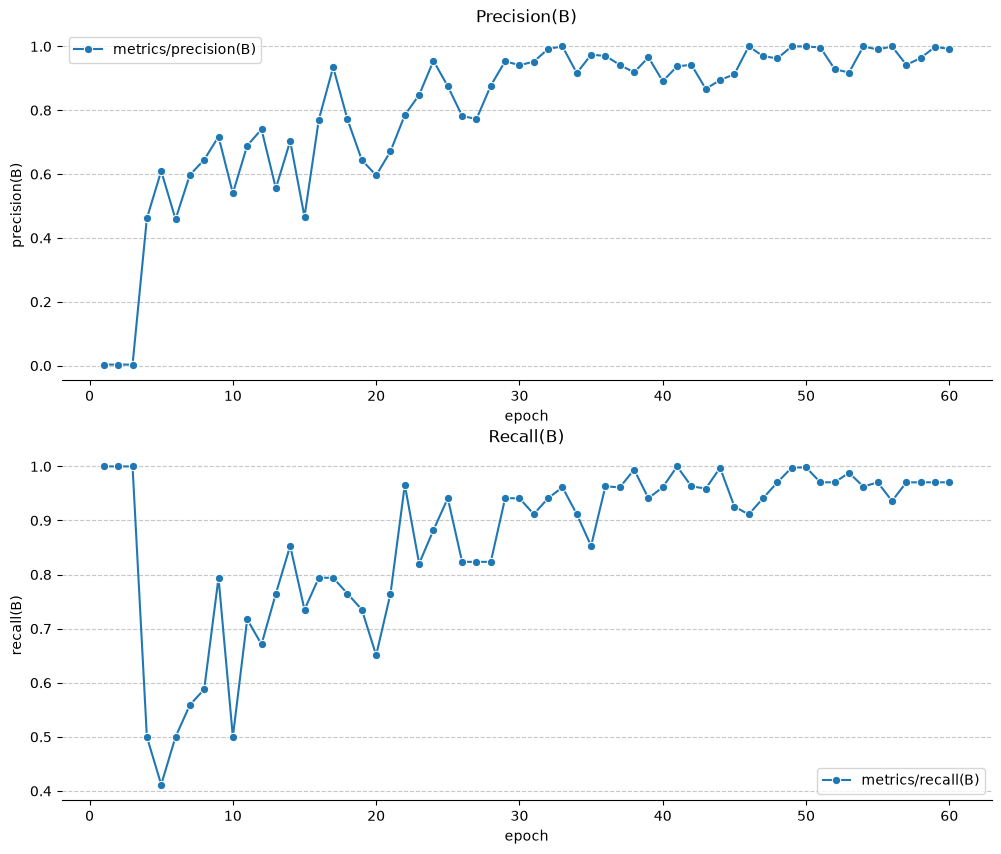

In [13]:
fig, (up, down) = plt.subplots(2, 1, figsize=(12, 10))

sns.lineplot(data=results_df, x='epoch', y='metrics/precision(B)', marker='o', linestyle='-', label='metrics/precision(B)', ax=up)
up.set_title("Precision(B)")
up.set_ylabel("precision(B)")
up.spines['top'].set_visible(False)
up.spines['right'].set_visible(False)
up.spines['left'].set_visible(False)
up.grid(axis='y', linestyle='--', alpha=0.7)


sns.lineplot(data=results_df, x='epoch', y='metrics/recall(B)', marker='o', linestyle='-', label='metrics/recall(B)', ax=down)
down.set_title("Recall(B)")
down.set_ylabel("recall(B)")
down.spines['top'].set_visible(False)
down.spines['right'].set_visible(False)
down.spines['left'].set_visible(False)
down.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

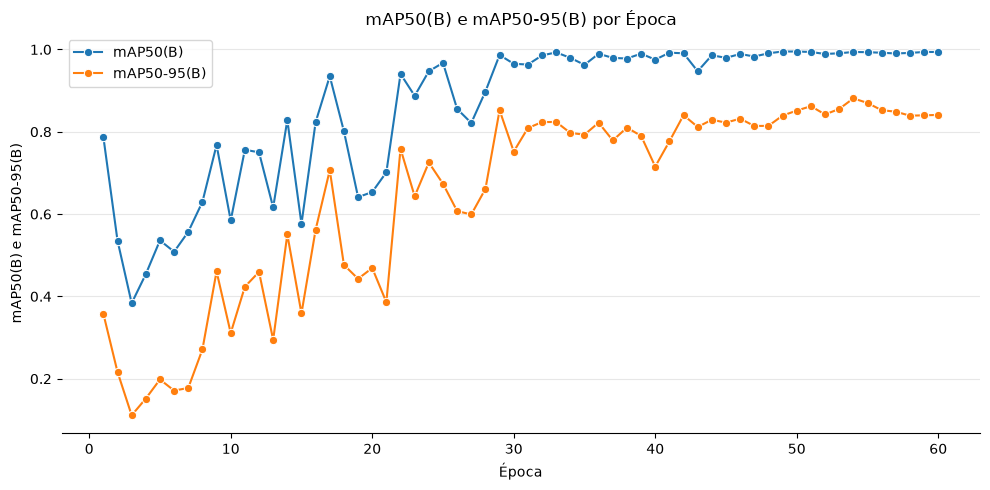

In [14]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=results_df, x='epoch', y='metrics/mAP50(B)', marker='o', linestyle='-', label='mAP50(B)')
sns.lineplot(data=results_df, x='epoch', y='metrics/mAP50-95(B)', marker='o', linestyle='-', label='mAP50-95(B)')
plt.title('mAP50(B) e mAP50-95(B) por Época')
plt.xlabel('Época')
plt.ylabel('mAP50(B) e mAP50-95(B)')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis = 'y', alpha=0.3)
plt.tight_layout()